# Сравнительный анализ двух подходов к подсчету площади через метод Монте-Карло


In [24]:
import subprocess
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10


In [25]:
# Компиляция C++ программы
cpp_file = "a1i_experiment.cpp"
exe_file = "a1i_experiment"

compile_cmd = f"g++ -std=c++11 -O2 -o {exe_file} {cpp_file}"

result = subprocess.run(compile_cmd, shell=True, capture_output=True, text=True, cwd="a1")

In [26]:
N_min = 100
N_max = 100000
N_step = 500
N_values = list(range(N_min, N_max + 1, N_step))

In [27]:
def run_experiment(n, region_type):
    cmd = f"./{exe_file} {n} {region_type}"
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True, cwd="a1")
    
    parts = result.stdout.strip().split()
    n_val = int(float(parts[0]))
    estimated = float(parts[1])
    exact = float(parts[2])
    return n_val, estimated, exact



In [28]:
from tqdm.notebook import tqdm
narrow_results = []

for n in tqdm(N_values):
    result = run_experiment(n, "narrow")
    narrow_results.append(result)
    
narrow_results = np.array(narrow_results)


  0%|          | 0/200 [00:00<?, ?it/s]

In [29]:
wide_results = []

for n in tqdm(N_values):
    result = run_experiment(n, "wide")
    wide_results.append(result)

wide_results = np.array(wide_results)


  0%|          | 0/200 [00:00<?, ?it/s]

In [ ]:

narrow_N = narrow_results[:, 0]
narrow_area = narrow_results[:, 1]
narrow_exact = narrow_results[:, 2]
narrow_re = np.abs((narrow_area - narrow_exact) / narrow_exact) * 100

wide_N = wide_results[:, 0]
wide_area = wide_results[:, 1]
wide_exact = wide_results[:, 2]
wide_re = np.abs((wide_area - wide_exact) / wide_exact) * 100

## График сходимости площади (узкая и широкая области)

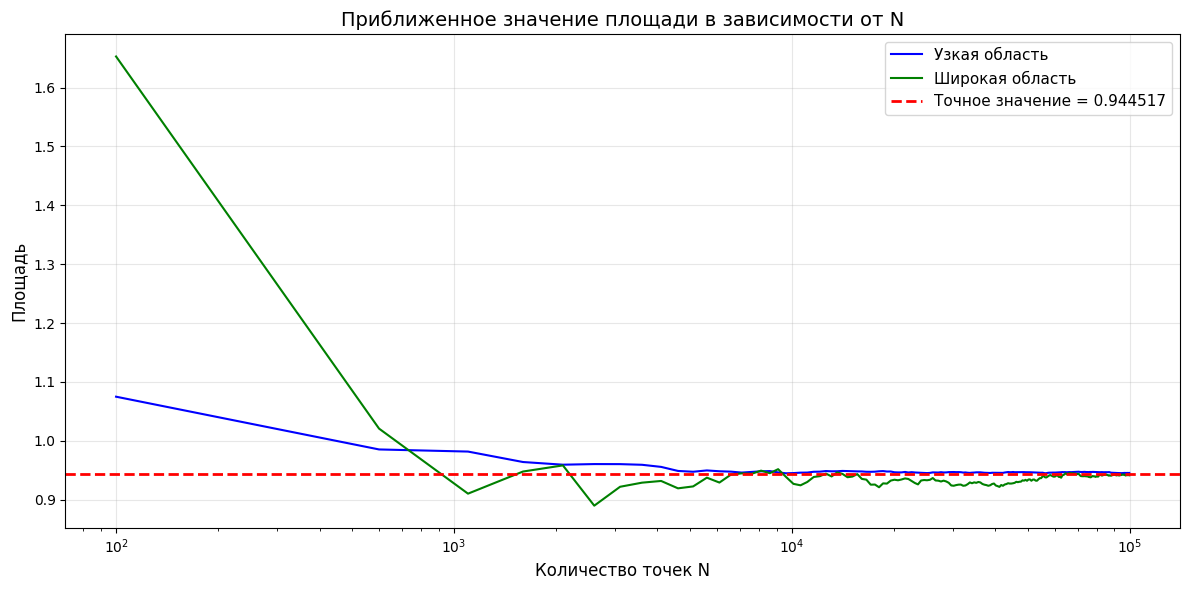

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(narrow_N, narrow_area, 'b-', linewidth=1.5, label='Узкая область')
plt.plot(wide_N, wide_area, 'g-', linewidth=1.5, label='Широкая область')
plt.axhline(y=narrow_exact[0], color='r', linestyle='--', linewidth=2, label=f'Точное значение = {narrow_exact[0]:.6f}')
plt.xlabel('Количество точек N', fontsize=12)
plt.ylabel('Площадь', fontsize=12)
plt.title('Приближенное значение площади в зависимости от N', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.tight_layout()
plt.show()


## График относительной ошибки

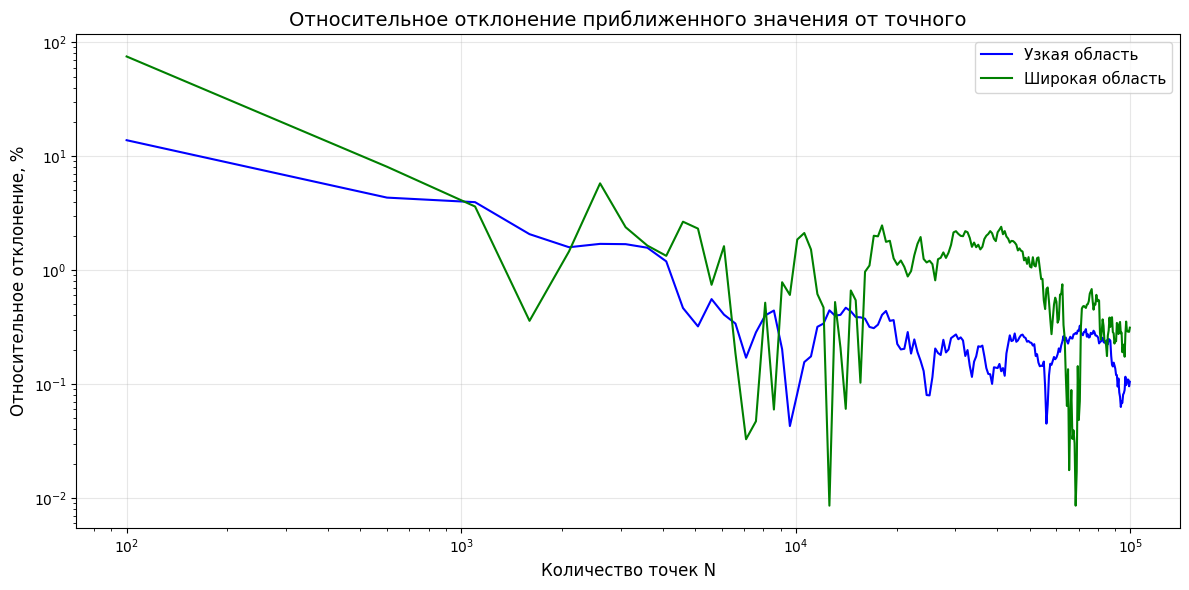

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(narrow_N, narrow_re, 'b-', linewidth=1.5, label='Узкая область')
plt.plot(wide_N, wide_re, 'g-', linewidth=1.5, label='Широкая область')
plt.xlabel('Количество точек N', fontsize=12)
plt.ylabel('Относительное отклонение, %', fontsize=12)
plt.title('Относительное отклонение приближенного значения от точного', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.yscale('log')
plt.tight_layout()
plt.show()


## Статистика по результатам экспериментов


## Интерпретация результатов

### Анализ зависимости точности от количества точек N

#### 1. Сходимость метода Монте-Карло
Из графиков видно, что с увеличением количества точек N:
- **Приближенное значение площади** стремится к точному значению (≈ 0.944517)
- **Относительное отклонение** уменьшается, следуя закону $O(1/\sqrt{N})$, что характерно для метода Монте-Карло
- При малых N (100-1000) наблюдается значительный разброс значений
- При больших N (10000-100000) значения стабилизируются и приближаются к точному

#### 2. Влияние масштаба области на точность

**Узкая область (narrow):**
- Используется минимальный bounding box пересечения всех трех кругов
- Площадь области генерации точек минимальна
- **Преимущества:** Больше точек попадает в целевую область, выше эффективность
- **Недостатки:** Меньше точек генерируется, но выше доля "полезных" точек

**Широкая область (wide):**
- Используется bounding box, охватывающий все три круга
- Площадь области генерации точек максимальна
- **Преимущества:** Больше точек генерируется
- **Недостатки:** Меньше доля точек попадает в целевую область, ниже эффективность

#### 3. Ключевые наблюдения

1. **Скорость сходимости:** Обе области демонстрируют сходимость к точному значению, но с разной скоростью
2. **Стабильность:** При больших N обе области дают стабильные результаты
3. **Эффективность:** Узкая область, как правило, более эффективна, так как большая доля сгенерированных точек попадает в целевую область
4. **Точность:** При одинаковом N узкая область часто дает более точные результаты из-за более высокой плотности точек в области пересечения

#### 4. Практические рекомендации

- Для **быстрых оценок** (N < 1000): можно использовать любую область, но узкая предпочтительнее
- Для **высокой точности** (N > 10000): обе области дают хорошие результаты, разница становится незначительной
- **Оптимальный выбор:** Узкая область предпочтительнее, так как обеспечивает лучшую эффективность использования вычислительных ресурсов
